In [1]:
# ================================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ================================================================
# CARREGANDO O DATASET
# ================================================================
california = fetch_california_housing()
X = california.data
y = california.target

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [3]:
# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# ================================================================
# MODELO 1 — ÁRVORE DE DECISÃO
# ================================================================
dt_regressor = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

dt_regressor.fit(X_train_scaled, y_train)
y_pred_dt = dt_regressor.predict(X_test_scaled)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\n===== Árvore de Decisão =====")
print("MSE:", mse_dt)
print("R² :", r2_dt)


===== Árvore de Decisão =====
MSE: 0.5211334618725708
R² : 0.6029580667515306


In [5]:
# ================================================================
# FUNÇÃO DE PLOT
# ================================================================
def plot_results(y_test, y_pred, title_extra=""):
    plt.figure(figsize=(14, 6))

    # Valores reais vs previstos
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7, s=20)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2)
    plt.xlabel("Valor Real")
    plt.ylabel("Valor Previsto")
    plt.title(f"Reais vs Previstos {title_extra}")

    # Histograma de erros
    errors = y_test - y_pred
    plt.subplot(1, 2, 2)
    plt.hist(errors, bins=25, edgecolor='k', alpha=0.7)
    plt.xlabel("Erro")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição dos Erros {title_extra}")

    plt.tight_layout()
    plt.show()

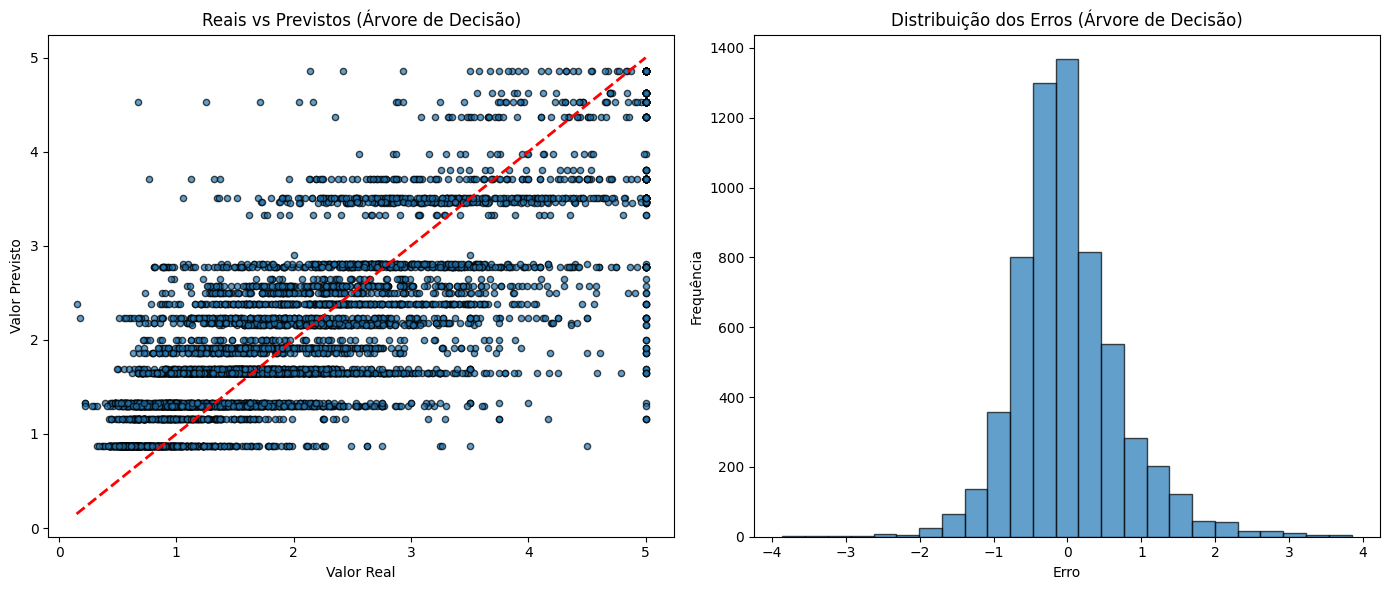

In [6]:
# Plot da árvore
plot_results(y_test, y_pred_dt, "(Árvore de Decisão)")


===== Random Forest =====
MSE: 0.29180685208035817
R² : 0.7776777636407737


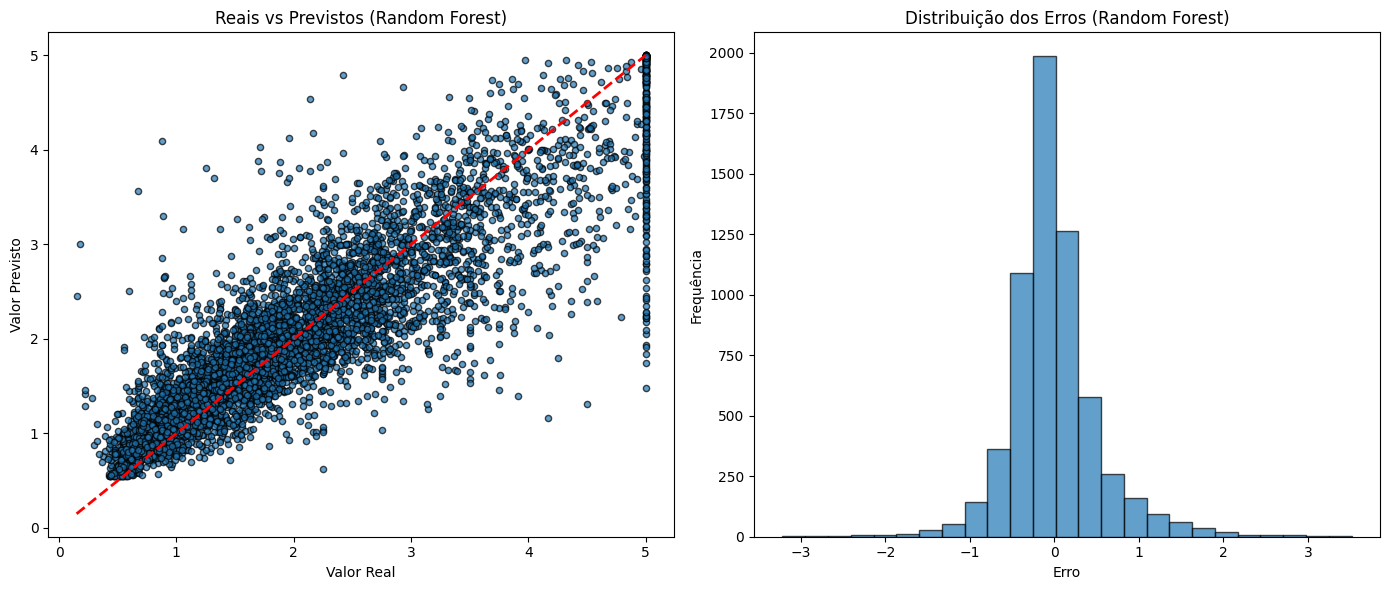

In [7]:
# ================================================================
# MODELO 2 — RANDOM FOREST
# ================================================================
rf_regressor = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_regressor.fit(X_train_scaled, y_train)
y_pred_rf = rf_regressor.predict(X_test_scaled)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n===== Random Forest =====")
print("MSE:", mse_rf)
print("R² :", r2_rf)

plot_results(y_test, y_pred_rf, "(Random Forest)")


===== Teste 1 — Decision Tree (max_depth=10) =====
MSE: 0.40100455814687164
R² : 0.6944820537219425


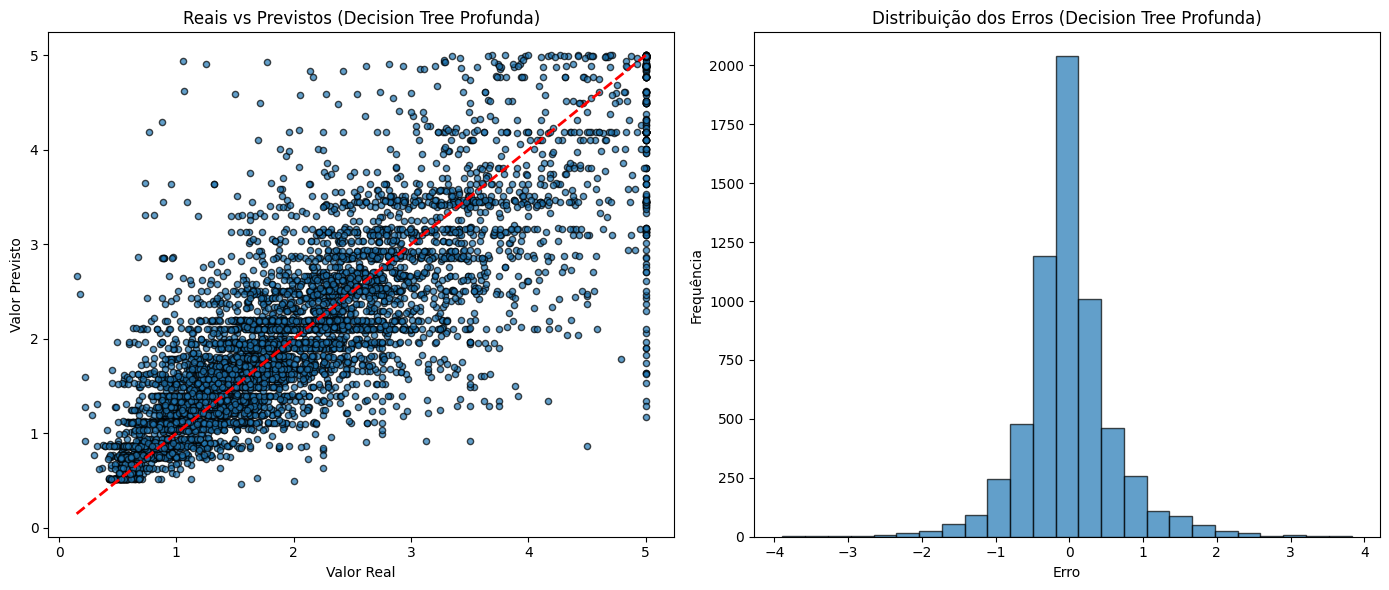

In [8]:
# ================================================================
# TESTE 1 — Árvore de Decisão mais profunda
# ================================================================
dt_regressor2 = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

dt_regressor2.fit(X_train_scaled, y_train)
y_pred_dt2 = dt_regressor2.predict(X_test_scaled)

mse_dt2 = mean_squared_error(y_test, y_pred_dt2)
r2_dt2 = r2_score(y_test, y_pred_dt2)

print("\n===== Teste 1 — Decision Tree (max_depth=10) =====")
print("MSE:", mse_dt2)
print("R² :", r2_dt2)

plot_results(y_test, y_pred_dt2, "(Decision Tree Profunda)")


===== Teste 2 — Random Forest (600 árvores) =====
MSE: 0.27009798441867217
R² : 0.7942173478656274


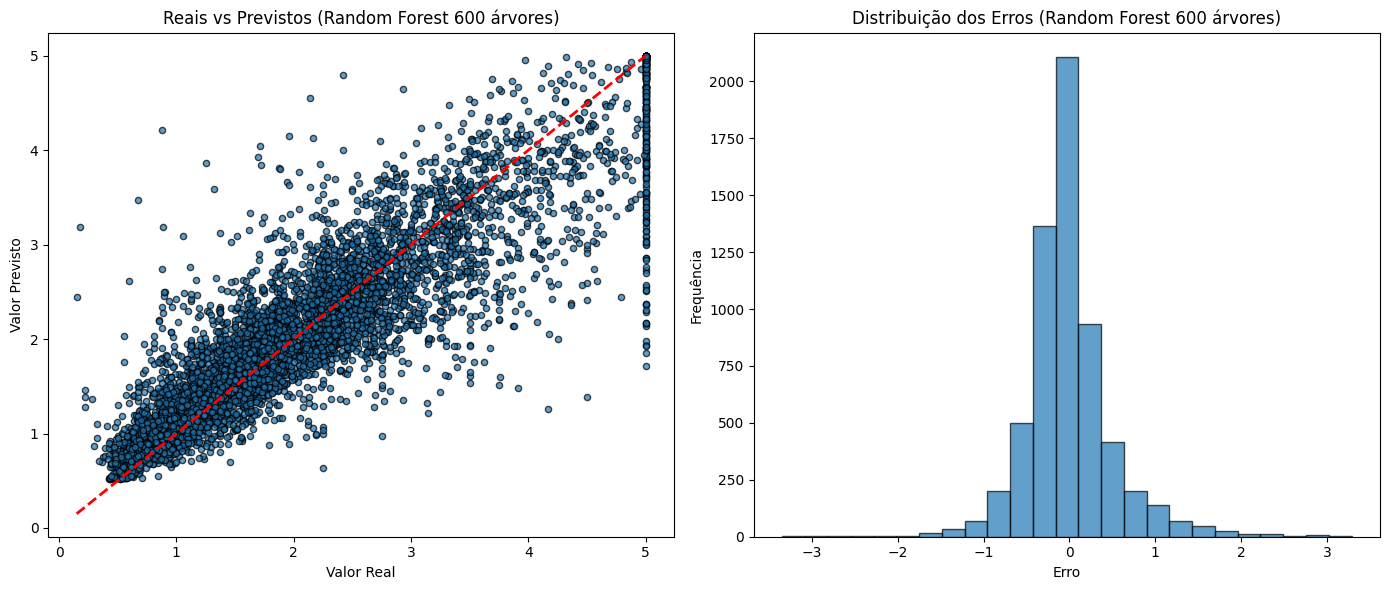

In [9]:
# ================================================================
# TESTE 2 — Random Forest com mais árvores
# ================================================================
rf_regressor2 = RandomForestRegressor(
    n_estimators=600,
    max_depth=12,
    random_state=42
)

rf_regressor2.fit(X_train_scaled, y_train)
y_pred_rf2 = rf_regressor2.predict(X_test_scaled)

mse_rf2 = mean_squared_error(y_test, y_pred_rf2)
r2_rf2 = r2_score(y_test, y_pred_rf2)

print("\n===== Teste 2 — Random Forest (600 árvores) =====")
print("MSE:", mse_rf2)
print("R² :", r2_rf2)

plot_results(y_test, y_pred_rf2, "(Random Forest 600 árvores)")

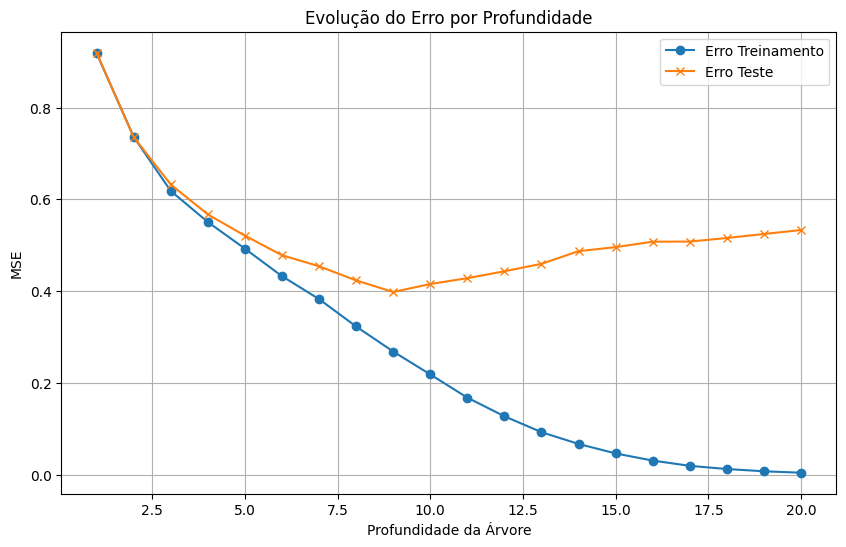

In [10]:
# ================================================================
# EVOLUÇÃO DO ERRO EM DIFERENTES PROFUNDIDADES
# ================================================================
depths = range(1, 21)
train_errors = []
test_errors = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, marker='o', label="Erro Treinamento")
plt.plot(depths, test_errors, marker='x', label="Erro Teste")
plt.xlabel("Profundidade da Árvore")
plt.ylabel("MSE")
plt.title("Evolução do Erro por Profundidade")
plt.grid(True)
plt.legend()
plt.show()